# Notebook 6 — Logistic Regression
### Sprint 7 | Machine Learning Fundamentals for AI/ML Engineers

**Algorithm documentation:** Algorithm Name -> What is it -> Problem Type -> Concept ->
Mathematical Intuition -> Example -> Implementation -> Parameters -> Result ->
Interpretation -> Advantages -> Limitations -> When to Use -> When Not to Use.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
encode_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])
df_encoded = df.copy()
for col in encode_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (5634, 19) | Test: (1409, 19)


/tmp/ipykernel_576/1108686300.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  encode_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])


---
## Algorithm Documentation

### What is the algorithm?
Logistic Regression predicts the PROBABILITY that an observation belongs to a class,
using a linear combination of features passed through a sigmoid function.

### Problem Type
**Classification** (binary here — `Churn` Yes/No).

### Concept — Why "Regression" for a Classification Algorithm?
Logistic Regression IS built on a linear regression core (`w1*x1 + w2*x2 + ... + b`) —
that's where "Regression" in the name comes from. But instead of outputting that raw
linear value directly as the prediction (which could be any number from -infinity to
+infinity, nonsensical for a probability), it passes that value through the **sigmoid
function**, squashing it into a valid probability between 0 and 1. The name reflects its
mathematical lineage, not its use case.

### Mathematical Intuition
Sigmoid function: $\sigma(z) = \frac{1}{1 + e^{-z}}$, where $z = w_1x_1 + ... + w_nx_n + b$.
As $z \to +\infty$, $\sigma(z) \to 1$; as $z \to -\infty$, $\sigma(z) \to 0$; at $z=0$,
$\sigma(z)=0.5$ exactly. A **decision boundary** then converts this probability into a
class label using a **threshold** (commonly 0.5): predict "Yes" if $\sigma(z) \geq 0.5$.
The model is trained by minimizing **Log Loss** (cross-entropy), which penalizes
confident-and-wrong predictions much more heavily than uncertain ones.

### Example


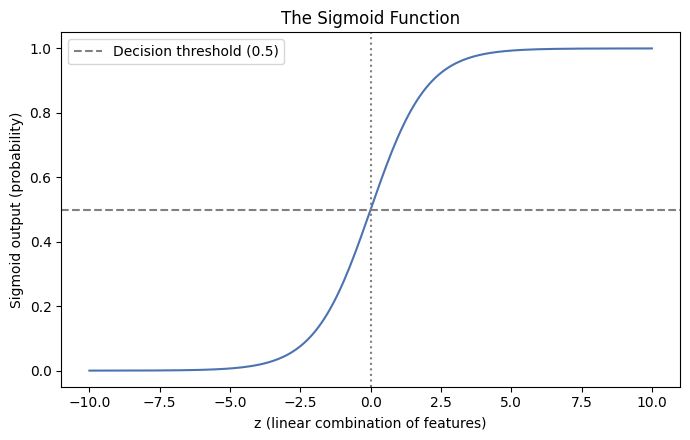

In [2]:
z_values = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z_values))

plt.figure(figsize=(7, 4.5))
plt.plot(z_values, sigmoid, color='#4C72B0')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision threshold (0.5)')
plt.axvline(0, color='gray', linestyle=':')
plt.xlabel('z (linear combination of features)')
plt.ylabel('Sigmoid output (probability)')
plt.title('The Sigmoid Function')
plt.legend()
plt.tight_layout()
plt.show()


### Implementation


In [3]:
model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Sample predicted probabilities (first 5): {y_pred_proba[:5].round(3)}")
print(f"Sample predicted classes (first 5)       : {y_pred[:5]}")


Sample predicted probabilities (first 5): [0.117 0.879 0.183 0.593 0.059]
Sample predicted classes (first 5)       : [0 1 0 1 0]


### Parameters
- **`max_iter`**: maximum optimization iterations for the solver to converge (increased
  from the default 100, since this dataset's scaled features need more steps).
- **`class_weight='balanced'`**: automatically weights classes inversely to their
  frequency, addressing the 73.5%/26.5% imbalance (Sprint 4, Notebook 10) without
  resampling the data itself.
- **`C`** (not explicitly set here, default 1.0): inverse regularization strength —
  smaller `C` means stronger regularization (simpler model, per Notebook 4's Ridge/Lasso
  concept, applied here to a classifier).

### Result


In [4]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print(f"\nTop 5 coefficients by magnitude:\n{coefficients.head(5).round(3)}")


Accuracy : 0.7388
Precision: 0.5051
Recall   : 0.7968
F1 Score : 0.6183

Top 5 coefficients by magnitude:
tenure           -1.112
MonthlyCharges    0.734
Contract         -0.633
TotalCharges      0.440
PhoneService     -0.286
dtype: float64


### Interpretation
Per Sprint 4/5's documented imbalance, `class_weight='balanced'` trades some precision
for higher recall — the model catches more true churners at the cost of more false
alarms. Whether this is the right trade-off is a BUSINESS decision (the cost of a missed
churner vs. a wasted retention offer), not purely a statistical one (Sprint 5, Notebook
11). The coefficients' signs and magnitudes should align with Sprint 4's known findings —
e.g., `Contract` should carry a large negative coefficient (longer contract = lower churn
probability).

### Advantages
- Fast to train, computationally cheap.
- Directly interpretable coefficients (each shows a feature's direction and relative
  strength of effect).
- Outputs genuine probabilities, not just hard class labels — useful for ranking
  customers by risk, not just classifying them.

### Limitations
- Assumes a roughly linear relationship between features and the LOG-ODDS of the
  outcome — cannot naturally capture complex non-linear patterns (like Sprint 4,
  Notebook 6's tenure x MonthlyCharges interaction) without manually engineering
  interaction terms first (Sprint 6, Notebook 6).
- Sensitive to unscaled features and multicollinearity (motivating the `StandardScaler`
  step and the VIF checks from Sprint 4-5).

### When to Use
When interpretability matters, when a genuine probability estimate (not just a label) is
needed, or as a fast, strong baseline before trying more complex models.

### When Not to Use
When the true relationship is highly non-linear and non-interacting features can't
capture it — a tree-based model (Notebooks 9-10) may perform meaningfully better with
less manual feature engineering effort.


---
## Summary

| Aspect | Finding |
|---|---|
| Problem Type | Binary classification |
| Core Mechanism | Linear combination -> sigmoid -> probability -> threshold |
| Key Parameter | `class_weight='balanced'` addresses the documented 2.77:1 imbalance |
| Strength | Fast, interpretable, outputs real probabilities |
| Weakness | Cannot natively capture non-linear feature interactions |

**Next notebook:** `07_KNN.ipynb` — a fundamentally different, distance-based approach
to the same classification problem.
